# JUG: Noise Models in Pulsar Timing

Pulsar TOA uncertainties have structure beyond simple white noise.  For J1909-3744 the
noise model includes contributions at different time scales and frequency dependencies:

| Process | Symbol | Chromatic? | Effect |
|---------|--------|-----------|--------|
| EFAC | $E$ | No | Rescales TOA uncertainties per backend |
| EQUAD | $Q$ | No | Adds in quadrature per backend — pulse-phase jitter floor |
| ECORR | $J$ | No | Epoch-level correlated noise — simultaneous TOAs share the same jitter |
| Red Noise | $A_{\rm red}$, $\gamma_{\rm red}$ | No | Achromatic low-frequency spin noise, $P(f) \propto f^{-\gamma}$ |
| DM Noise | $A_{\rm DM}$, $\gamma_{\rm DM}$ | Yes ($\propto\nu^{-2}$) | Stochastic ISM dispersion variations |

ECORR operates within observing epochs (time-correlated).  Red noise and DM noise are
Fourier-basis Gaussian processes marginalised analytically in the GLS solver.
DM noise is chromatic: the same DM fluctuation shifts TOAs at different frequencies by
different amounts ($\Delta t \propto \nu^{-2}$), so it is separable from spin noise using
multi-frequency data.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress PjRt C++ log spam

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from jug.engine.session import TimingSession
from jug.engine.flag_mapping import resolve_backends

# noise_demo par: NANOGrav timing model + EFAC/EQUAD/ECORR + TNRedAmp/TNRedGam + TNDMAmp/TNDMGam
# DM1/DM2 free (polynomial drift); red noise + DM noise as stochastic Fourier processes
PAR   = "../data/pulsars/J1909-3744_noise_demo.par"
TIM   = "../data/pulsars/NG_15yr_partim/J1909-3744_PINT_20220303.nb.tim"
CLOCK = "../data/clock"

> **Performance note:** The first execution compiles JAX kernels for this machine (~1–3 minutes).
> Subsequent runs use the on-disk compilation cache and complete in seconds.
> Run this notebook once before your presentation to warm the cache.

## Load and fit

In [2]:
session = TimingSession(PAR, TIM, clock_dir=CLOCK, verbose=False)
fit = session.fit_parameters(max_iter=3, verbose=False)

mjd      = np.array(fit['tdb_mjd'])
res_us   = np.array(fit['residuals_us'])
pre_us   = np.array(fit['residuals_prefit_us'])
err_us   = np.array(fit['errors_us'])
freq_mhz = np.array([t.freq_mhz for t in session.toas_data])
noise    = fit['noise_realizations']

noise_keys = [k for k in noise if not k.endswith('_err')]
print("Noise realizations:", noise_keys)
print(f"TOAs: {len(mjd)}   Post-fit RMS: {fit['final_rms']:.4f} µs")

[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL


[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[SETUP] Building DM NOISE basis: 60 columns


Noise realizations: ['RedNoise', 'DMNoise', 'ECORR']
TOAs: 35037   Post-fit RMS: 0.2893 µs


## Backend colouring

J1909-3744 was observed by five receiver+backend combinations.  We colour each
separately so that chromatic effects (DM noise) are visible as frequency-dependent
offsets across colours at the same epoch.

In [3]:
toa_flags   = [t.flags for t in session.toas_data]
backend_arr = resolve_backends(toa_flags)
unique_backends = sorted(set(backend_arr))

PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22', '#1abc9c']
bknd_colors = {b: PALETTE[i % len(PALETTE)] for i, b in enumerate(unique_backends)}

print("Backends:", unique_backends)

Backends: ['3GHz_YUPPI', 'Rcvr1_2_GASP', 'Rcvr1_2_GUPPI', 'Rcvr_800_GASP', 'Rcvr_800_GUPPI']


## ECORR: epoch-level correlated noise

Each cluster of points at the same MJD (same observing session, different frequency
sub-bands) shares one ECORR jitter value.  The realization is constant within each
epoch — visible as a common offset at every colour simultaneously.

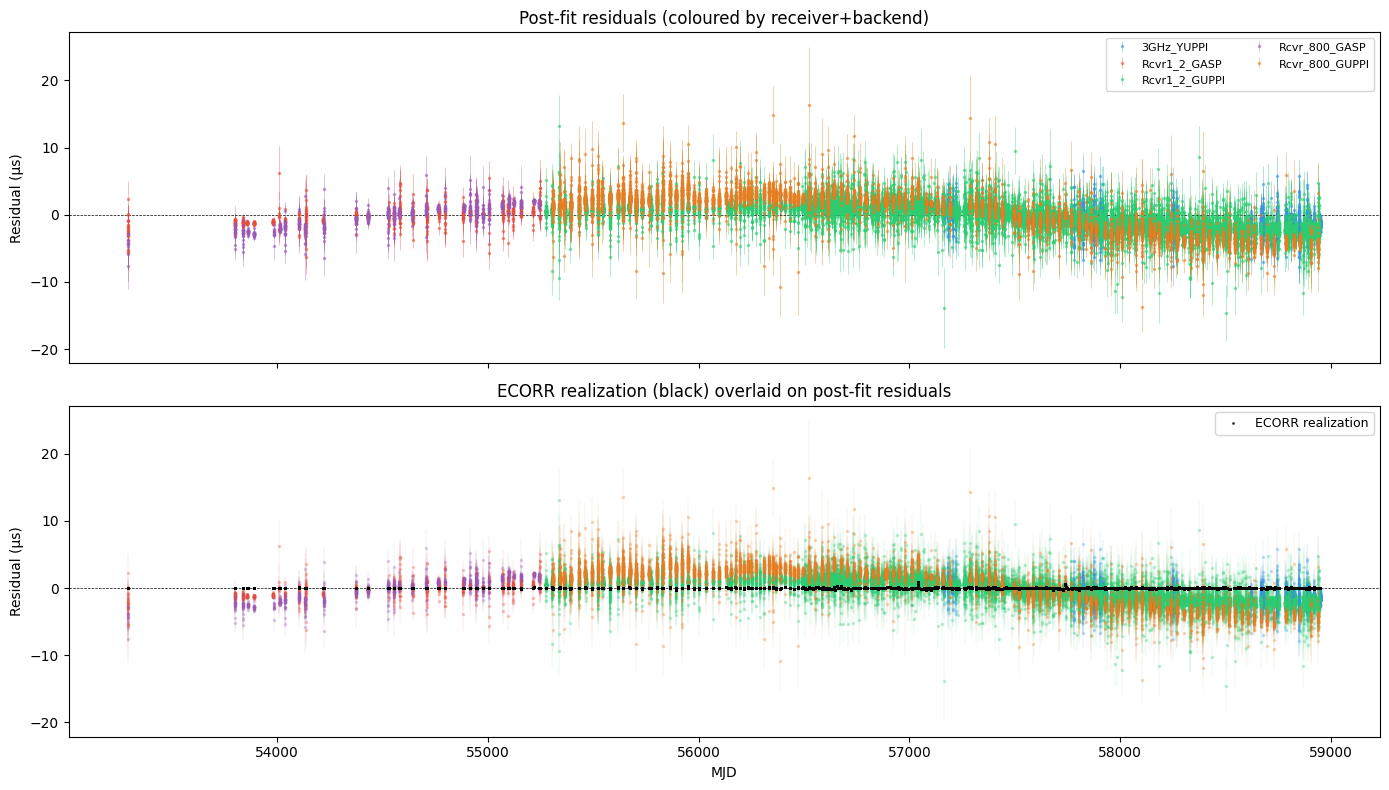

In [4]:
ecorr_us = noise.get('ECORR', np.zeros_like(res_us))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Post-fit residuals coloured by backend
ax = axes[0]
for b in unique_backends:
    mask = np.array(backend_arr) == b
    ax.errorbar(mjd[mask], res_us[mask], err_us[mask],
                fmt='.', ms=3, alpha=0.5, color=bknd_colors[b],
                elinewidth=0.5, label=b)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Residual (µs)')
ax.set_title('Post-fit residuals (coloured by receiver+backend)')
ax.legend(loc='upper right', ncol=2, fontsize=8)

# ECORR realization overlaid
ax = axes[1]
for b in unique_backends:
    mask = np.array(backend_arr) == b
    ax.errorbar(mjd[mask], res_us[mask], err_us[mask],
                fmt='.', ms=3, alpha=0.25, color=bknd_colors[b],
                elinewidth=0.3)
ax.plot(mjd, ecorr_us, 'k.', ms=2, alpha=0.7, label='ECORR realization', zorder=5)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Residual (µs)')
ax.set_title('ECORR realization (black) overlaid on post-fit residuals')
ax.legend(fontsize=9)
ax.set_xlabel('MJD')

plt.tight_layout()
plt.show()

## All noise components: separate panels

Each process is shown independently.  Red noise is achromatic (all backends shift
together).  DM noise is chromatic: the offset scales as $\nu^{-2}$, so lower-frequency
backends are shifted more — look for colour separation within DM noise.

In [ ]:
NOISE_COLORS = {'ECORR': '#e74c3c', 'RedNoise': '#3498db',
                'DMNoise': '#2ecc71', 'ChromaticNoise': '#9b59b6'}
label_map = {'ECORR': 'ECORR (jitter)', 'RedNoise': 'Red noise (achromatic)',
             'DMNoise': 'DM noise (chromatic ∝ν⁻²)'}
total_noise = np.zeros(len(res_us))
for k in noise_keys:
    v = np.array(noise[k])
    if len(v) == len(res_us):
        total_noise += v
n_panels = len(noise_keys)
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3.5 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]
for ax, k in zip(axes, noise_keys):
    v = np.array(noise[k])
    color = NOISE_COLORS.get(k, '#e67e22')
    if k == 'DMNoise':
        for b in unique_backends:
            mask = np.array(backend_arr) == b
            ax.plot(mjd[mask], v[mask], '.', ms=3, alpha=0.7, color=bknd_colors[b], label=b)
        ax.legend(loc='upper right', ncol=2, fontsize=7, title='backend (ν⁻² scaling)')
    else:
        ax.plot(mjd, v, '.', ms=2, color=color, alpha=0.7)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    rms_n = np.sqrt(np.mean(v ** 2))
    ax.set_ylabel(f'{label_map.get(k, k)}\n(µs)')
    ax.set_title(f'{label_map.get(k, k)}   RMS = {rms_n:.4f} µs')
axes[-1].set_xlabel('MJD')
fig.suptitle('J1909-3744: individual noise realizations', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Pre-fit → Post-fit → Whitened

Subtracting all noise realizations from the post-fit residuals gives the **whitened**
residuals.  These should be purely white if the noise model is complete.

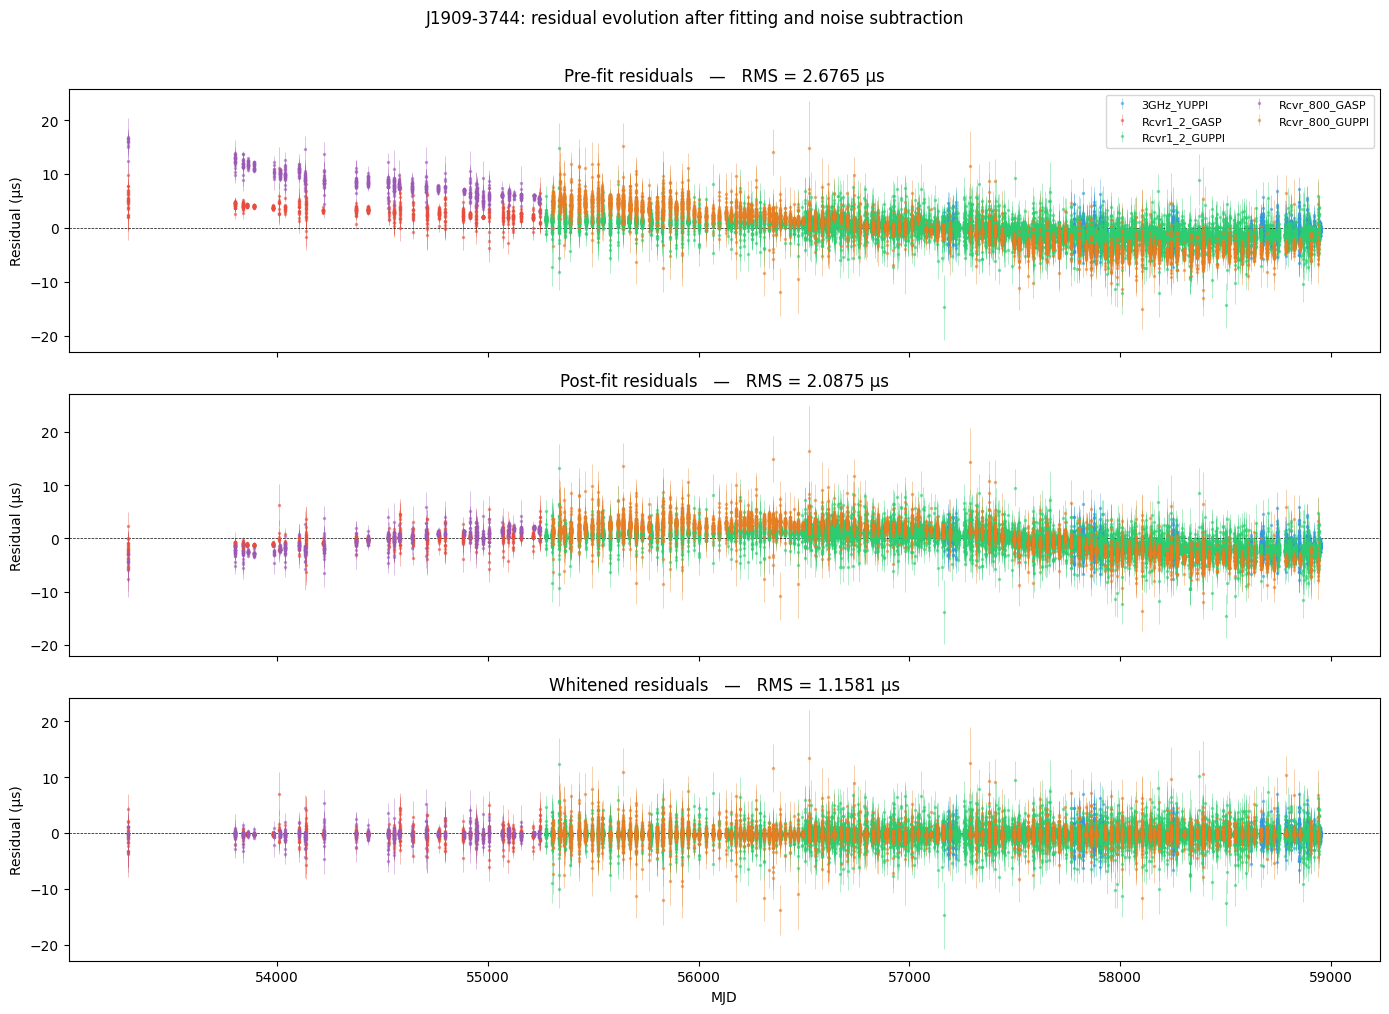

In [6]:
whitened_us = res_us - total_noise

prefit_rms  = np.sqrt(np.mean(pre_us**2))
postfit_rms = np.sqrt(np.mean(res_us**2))
white_rms   = np.sqrt(np.mean(whitened_us**2))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, y, title, rms in [
    (axes[0], pre_us,      'Pre-fit residuals',      prefit_rms),
    (axes[1], res_us,      'Post-fit residuals',     postfit_rms),
    (axes[2], whitened_us, 'Whitened residuals',     white_rms),
]:
    for b in unique_backends:
        mask = np.array(backend_arr) == b
        ax.errorbar(mjd[mask], y[mask], err_us[mask],
                    fmt='.', ms=3, alpha=0.5, color=bknd_colors[b],
                    elinewidth=0.5, label=b)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel('Residual (µs)')
    ax.set_title(f"{title}   —   RMS = {rms:.4f} µs")

axes[0].legend(loc='upper right', ncol=2, fontsize=8)
axes[-1].set_xlabel('MJD')
fig.suptitle('J1909-3744: residual evolution after fitting and noise subtraction',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Gaussianity of whitened residuals

If the noise model is correctly specified, whitened residuals normalised by the TOA
uncertainty should follow $\mathcal{N}(0,1)$.

In [ ]:
from scipy.stats import anderson, norm, probplot

whitened_norm = (whitened_us - whitened_us.mean()) / err_us

ad_result = anderson(whitened_norm, dist='norm')
sig_level = None
for stat_val, crit_val, sig in zip(
        [ad_result.statistic]*len(ad_result.critical_values),
        ad_result.critical_values,
        ad_result.significance_level):
    if stat_val < crit_val:
        sig_level = sig
        break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
x_range = np.linspace(-5, 5, 200)
ax1.hist(whitened_norm, bins=60, density=True, alpha=0.6, color='#3498db',
         edgecolor='white', linewidth=0.5, label='Whitened / σ')
ax1.plot(x_range, norm.pdf(x_range), 'k-', lw=2, label='N(0,1)')
ax1.set_xlabel('Normalised whitened residual')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of normalised whitened residuals')
ax1.legend()
probplot(whitened_norm, dist='norm', plot=ax2)
ax2.set_title('Q–Q plot (whitened / σ vs Normal)')
plt.tight_layout()
plt.show()

print(f"Anderson–Darling statistic: {ad_result.statistic:.4f}")
print(f"Critical values (15%, 10%, 5%, 2.5%, 1%): {ad_result.critical_values}")
if sig_level is not None:
    print(f"Cannot reject N(0,1) at {sig_level}% significance level")
else:
    print("Reject N(0,1) — noise model may be incomplete")

## Noise model parameter summary

In [8]:
import re

# White noise parameters from par file
efac_vals = {}; equad_vals = {}; ecorr_vals = {}
with open(PAR) as f:
    for line in f:
        parts = line.split()
        if not parts:
            continue
        key = parts[0].upper()
        if key == 'EFAC' and len(parts) >= 4:
            efac_vals[parts[2]] = float(parts[3])
        elif key == 'EQUAD' and len(parts) >= 4:
            equad_vals[parts[2]] = float(parts[3])
        elif key == 'ECORR' and len(parts) >= 4:
            ecorr_vals[parts[2]] = float(parts[3])

print("White noise (per backend)")
print(f"{'Backend':<25} {'EFAC':>8} {'EQUAD (µs)':>12} {'ECORR (µs)':>12}")
print('-' * 62)
for b in sorted(set(list(efac_vals) + list(ecorr_vals))):
    print(f"{b:<25} {efac_vals.get(b, '-'):>8} {equad_vals.get(b, '-'):>12} {ecorr_vals.get(b, '-'):>12}")

print()
print("Stochastic red-noise processes (power-law Fourier GP)")
print(f"{'Process':<20} {'log₁₀(A)':>12} {'γ (spectral)':>14} {'N harmonics':>13}")
print('-' * 62)

# Read red-noise params from par
red_keys = {'TNRedAmp': None, 'TNRedGam': None, 'TNRedC': None,
            'TNDMAmp': None, 'TNDMGam': None, 'TNDMC': None}
with open(PAR) as f:
    for line in f:
        parts = line.split()
        if parts and parts[0] in red_keys:
            red_keys[parts[0]] = parts[1]

if red_keys['TNRedAmp']:
    print(f"{'Red noise (achrom.)':<20} {float(red_keys['TNRedAmp']):>12.4f} "
          f"{float(red_keys['TNRedGam']):>14.4f} {int(red_keys['TNRedC'] or 30):>13}")
if red_keys['TNDMAmp']:
    print(f"{'DM noise (chrom.)':<20} {float(red_keys['TNDMAmp']):>12.4f} "
          f"{float(red_keys['TNDMGam']):>14.4f} {int(red_keys['TNDMC'] or 30):>13}")

White noise (per backend)
Backend                       EFAC   EQUAD (µs)   ECORR (µs)
--------------------------------------------------------------
3GHz_YUPPI                0.9934148674247274 0.003332700805233785 0.0746538956355126
Rcvr1_2_GASP              0.929772586869957 0.06017662080686857 0.004408425713748998
Rcvr1_2_GUPPI             1.0326837908759976 0.00920930543356398 0.06852130522104043
Rcvr_800_GASP             1.0064598052278226 0.1407841460997482 0.049231466169632775
Rcvr_800_GUPPI            1.0243922050519814 0.03918145272830208 0.05232741757555693

Stochastic red-noise processes (power-law Fourier GP)
Process                  log₁₀(A)   γ (spectral)   N harmonics
--------------------------------------------------------------
Red noise (achrom.)      -14.2789         4.3300            30
DM noise (chrom.)        -13.6005         2.0414            30


## Takeaway

- **EFAC/EQUAD**: diagonal — only scale or add to per-TOA variance.  No inter-TOA
  covariance.
- **ECORR**: introduces off-diagonal covariance *within* each observing epoch.
  The realization is a constant offset per epoch — visible as coherent spikes at
  individual MJDs regardless of frequency.
- **Red noise** (achromatic): a long-timescale, frequency-independent spin-irregularity.
  Its steep spectrum ($\gamma \approx 4.3$) means it dominates at the lowest Fourier
  frequencies.  All backends shift by the same amount at every epoch.
- **DM noise** (chromatic $\propto\nu^{-2}$): stochastic ISM fluctuations on top of the
  smooth DM polynomial (DM1/DM2).  Its shallower spectrum ($\gamma \approx 2.0$) spreads
  power over more frequency bins.  Within each epoch, different frequencies are offset
  proportionally to $\nu^{-2}$ — the backend-coloured DM noise panel shows this spread.
- JUG marginalises all of these analytically in a single augmented SVD solve, giving
  MAP-optimal parameter estimates and correctly inflated uncertainties in one pass.

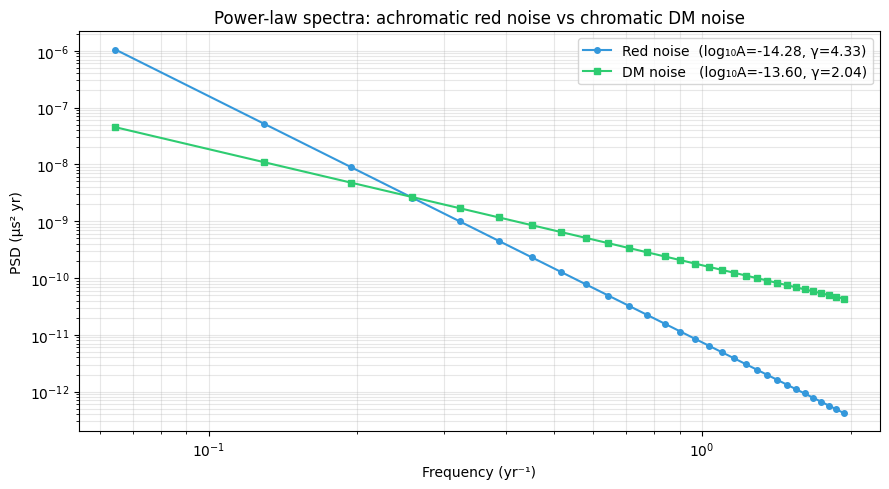

In [9]:
from jug.noise.red_noise import powerlaw_spectrum
import numpy as np

Tspan_yr = (mjd.max() - mjd.min()) / 365.25
f_fund = 1.0 / (Tspan_yr * 3.15576e7)   # fundamental freq in Hz
freqs  = np.array([k * f_fund for k in range(1, 31)])
freqs_yr = freqs * 3.15576e7             # Hz → yr⁻¹

rn_log10A = float(red_keys['TNRedAmp'])
rn_gamma  = float(red_keys['TNRedGam'])
dm_log10A = float(red_keys['TNDMAmp'])
dm_gamma  = float(red_keys['TNDMGam'])

P_red = powerlaw_spectrum(freqs, rn_log10A, rn_gamma) * 1e12   # s² → µs²
P_dm  = powerlaw_spectrum(freqs, dm_log10A, dm_gamma) * 1e12

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(freqs_yr, P_red, '-o', ms=4, color='#3498db',
          label=f'Red noise  (log₁₀A={rn_log10A:.2f}, γ={rn_gamma:.2f})')
ax.loglog(freqs_yr, P_dm,  '-s', ms=4, color='#2ecc71',
          label=f'DM noise   (log₁₀A={dm_log10A:.2f}, γ={dm_gamma:.2f})')
ax.set_xlabel('Frequency (yr⁻¹)')
ax.set_ylabel('PSD (µs² yr)')
ax.set_title('Power-law spectra: achromatic red noise vs chromatic DM noise')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()